In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv("/kaggle/input/datasets/pratyushpuri/retail-fashion-boutique-data-sales-analytics-2025/fashion_boutique_dataset.csv")
df.head()

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,stock_quantity,customer_rating,is_returned,return_reason
0,FB000001,Outerwear,Zara,Spring,XL,Red,196.01,0.0,196.01,2025-07-05,37,3.0,False,NaN
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,2025-08-06,2,2.5,False,NaN
2,FB000003,Accessories,Uniqlo,Winter,NaN,Black,33.80,0.0,33.80,2025-08-06,22,4.3,False,NaN
3,FB000004,Shoes,Uniqlo,Spring,XL,Black,75.36,0.0,75.36,2025-07-07,48,2.6,False,NaN
4,FB000005,Tops,Banana Republic,Winter,XL,Black,105.02,0.0,105.02,2025-08-06,10,NaN,False,NaN


In [57]:
df.shape
df.columns

Index(['product_id', 'category', 'brand', 'season', 'size', 'color',
       'original_price', 'markdown_percentage', 'current_price',
       'purchase_date', 'stock_quantity', 'customer_rating', 'is_returned',
       'return_reason'],
      dtype='object')

In [58]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

categorical_cols = ['category','brand','season','size','color']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [59]:
df['calculated_price'] = df['original_price'] * (1 - df['markdown_percentage'])
price_difference = (df['calculated_price'] - df['current_price']).abs().sum()
price_difference

np.float64(2520618.3329999996)

In [60]:
df.isnull().sum()

product_id                0
category                  0
brand                     0
season                    0
size                    491
color                     0
original_price            0
markdown_percentage       0
current_price             0
purchase_date             0
stock_quantity            0
customer_rating         362
is_returned               0
return_reason          1856
calculated_price          0
dtype: int64

In [61]:
df.groupby('is_returned')['customer_rating'].mean()

is_returned
False    2.988228
True     2.977239
Name: customer_rating, dtype: float64

In [62]:
return_rate = df['is_returned'].mean()
return_rate

np.float64(0.14705882352941177)

In [63]:
df['discount_amount'] = df['original_price'] - df['current_price']
df['purchase_month'] = df['purchase_date'].dt.month

In [64]:
df.groupby('is_returned')['markdown_percentage'].mean()

is_returned
False    12.038093
True     12.763125
Name: markdown_percentage, dtype: float64

In [65]:
df.groupby('is_returned')['customer_rating'].mean()

is_returned
False    2.988228
True     2.977239
Name: customer_rating, dtype: float64

In [67]:
df.groupby('size', observed=True)['is_returned'].mean().sort_values(ascending=False)


size
L      0.175824
XS     0.159468
XL     0.155477
S      0.136054
M      0.133333
XXL    0.132616
Name: is_returned, dtype: float64

In [69]:
df.groupby('brand', observed=True)['stock_quantity'].mean()

brand
Ann Taylor         25.929961
Banana Republic    24.400000
Forever21          25.712000
Gap                25.040984
H&M                23.173145
Mango              25.345070
Uniqlo             25.115385
Zara               24.993610
Name: stock_quantity, dtype: float64

In [71]:
df.groupby('brand', observed=True)['customer_rating'].mean()

brand
Ann Taylor         3.094286
Banana Republic    3.005907
Forever21          2.969811
Gap                3.034673
H&M                3.036481
Mango              2.777500
Uniqlo             3.110599
Zara               2.905639
Name: customer_rating, dtype: float64

In [73]:
df.groupby('season', observed=True)['markdown_percentage'].mean()

season
Fall      12.096140
Spring    11.839439
Summer    12.492348
Winter    12.125287
Name: markdown_percentage, dtype: float64

In [74]:
df[['original_price','markdown_percentage','current_price','customer_rating']].corr()

,original_price,markdown_percentage,current_price,customer_rating
original_price,1.000000,-0.010938,0.915059,0.005565
markdown_percentage,-0.010938,1.000000,-0.368419,-0.000878
current_price,0.915059,-0.368419,1.000000,0.000016
customer_rating,0.005565,-0.000878,0.000016,1.000000


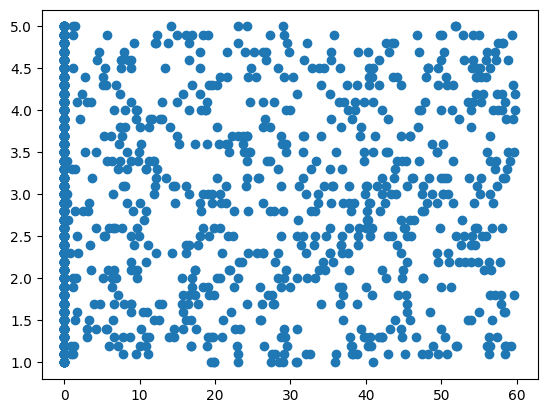

In [75]:
plt.scatter(df['markdown_percentage'], df['customer_rating'])
plt.show()